In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# specify GA results folder here
ga_run = 'ga_20221012-084817'

path = 'Results/' + ga_run

In [3]:
with open(path + '/params.json') as f:
    params = json.loads(f.read())

In [4]:
fitnesses_all = []
for i in range(1, params['generations'] + 1):
    fitnesses_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())
                try:
                    fitnesses_generation.append(results['fitness'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    fitnesses_generation.append(0)
        fitnesses_all.append(fitnesses_generation)
    except:
        pass

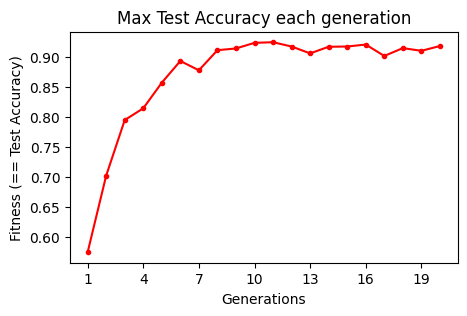

In [33]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness (== Test Accuracy)')
plt.title("Max Test Accuracy each generation")
plt.show()

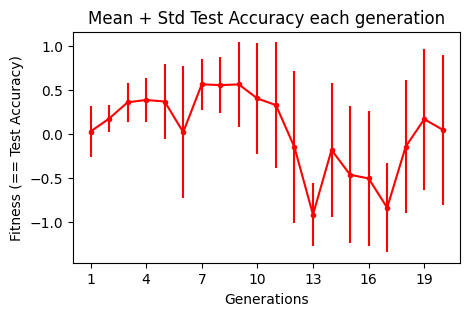

In [31]:
plt.figure(figsize=(5, 3))
plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.mean(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1), fmt='r.-')
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness (== Test Accuracy)')
plt.title("Mean + Std Test Accuracy each generation")
plt.show()

In [12]:
memory_footprints_all = []
for i in range(1, params['generations'] + 1):
    footprints_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())         
                try:
                    footprints_generation.append(results['memory_footprint'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    footprints_generation.append(0)
        memory_footprints_all.append(footprints_generation)
    except:
        pass

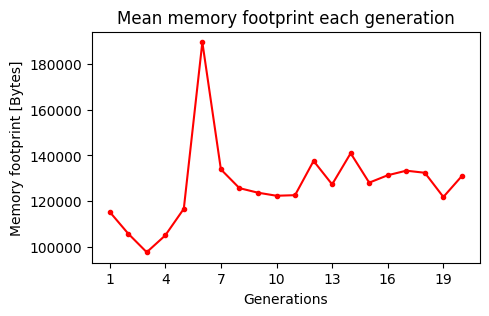

In [30]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), np.std(memory_footprints_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Memory footprint [Bytes]')
plt.title("Mean memory footprint each generation")
plt.show()